# Evaluating LLM Prompting Strategies for Subjective Scoring Tasks

**Project context:**  
This project evaluates how large language models perform on subjective scoring tasks by predicting numerical wine ratings from free-text tasting notes. I compare zero-shot, few-shot, and chain-of-thought prompting strategies, benchmark performance against a simple mean baseline, and analyze both prediction error and variance to understand reliability and uncertainty in LLM outputs.

## Setup

In [ ]:
!pip -q install gdown

from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
import re

## Dataset Overview

Load the wine reviews dataset and examine the distribution of expert-assigned scores.

In [ ]:
df = pd.read_csv('wine_reviews.csv')

display(df.head(2))
print('\n')
display(df['points'].describe())

,description,points
0,There's a surprising element of power to this ...,93
1,"Still youthful and vibrant, the 2007 Taylors P...",90


,points
count,200.000000
mean,88.370000
std,2.850214
min,81.000000
25%,87.000000
50%,88.000000
75%,90.000000
max,96.000000


## Zero-shot Prompting with Strict Output Constraints

This section establishes a zero-shot baseline: the model receives a review and returns a single integer score (80–100). A strict output format is enforced so predictions can be parsed reliably and evaluated at scale.

In [ ]:
!pip -q install openai

import os
from openai import OpenAI

# If running locally, set your API key like this (do not commit a real key):
# os.environ["OPENAI_API_KEY"] = "____________________________________"

api_key = os.environ.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY environment variable not set.")

client = OpenAI(api_key=api_key)

In [ ]:
# Zero-shot prompt with strict output constraint (80-100)
def predict_wine_score_zero_shot(review_text: str) -> str:
    prompt = (
        "You are a quality rater for different wines.\n"
        "Task: Predict the quality score for the description.\n"
        "Label definition:\n"
        "- 80 = acceptable score\n"
        "- 100 = best score\n\n"
        "Return ONLY a number in the range: 80 - 100. No words, no punctuation, no extra text.\n\n"
        f"Review: {review_text}"
    )

    response = client.responses.create(
        model="gpt-5-nano",
        input=prompt
    )

    return response.output_text

def parse_score(x):
    if isinstance(x, str) and x.strip().isdigit():
        val = int(x.strip())
        if 80 <= val <= 100:
            return val
    return None


# Test the prompt on 10 reviews
test_df = df.iloc[:10].copy()
test_df["raw_output"] = test_df["description"].apply(predict_wine_score_zero_shot)

test_df["pred_points"] = test_df["raw_output"].apply(parse_score)
test_df["valid_format"] = test_df["pred_points"].notna()

test_df[["points", "raw_output", "valid_format", "pred_points"]]


,points,raw_output,valid_format,pred_points
0,93,93,True,93
1,90,90,True,90
2,90,90,True,90
3,95,92,True,92
4,83,88,True,88
5,86,86,True,86
6,81,80,True,80
7,88,90,True,90
8,87,89,True,89
9,89,83,True,83


Model outputs are parsed into integer scores only when they meet the strict formatting and range requirements. Outputs that do not conform are treated as invalid, allowing format compliance to be evaluated alongside prediction accuracy.

**Why strict output constraints matter**  
Strict output constraints ensure model predictions are machine-readable and directly usable in downstream analysis. By enforcing a single numeric output, predictions can be reliably compared to ground-truth labels and evaluated quantitatively without additional cleaning or assumptions.

## Applying Zero-shot Scoring at Scale

Apply the zero-shot scoring function across the full dataset to generate predictions for evaluation.

In [ ]:
# Apply zero-shot scoring to the entire dataset

df["score_zero_shot_raw"] = df["description"].apply(predict_wine_score_zero_shot)

df["score_zero_shot"] = df["score_zero_shot_raw"].apply(parse_score)

df[["description", "points", "score_zero_shot"]].head()

,description,points,score_zero_shot
0,There's a surprising element of power to this ...,93,92
1,"Still youthful and vibrant, the 2007 Taylors P...",90,90
2,This is the rare Côtes du Rhône that needs cel...,90,92
3,"A rich, nutty note hints at hazelnut, with liv...",95,93
4,Powdered sugar and lifted lemon scents mark th...,83,92


## Baseline Comparison: Zero-shot vs. Mean Predictor

Zero-shot MAE: 2.485
Mean Baseline MAE: 2.234


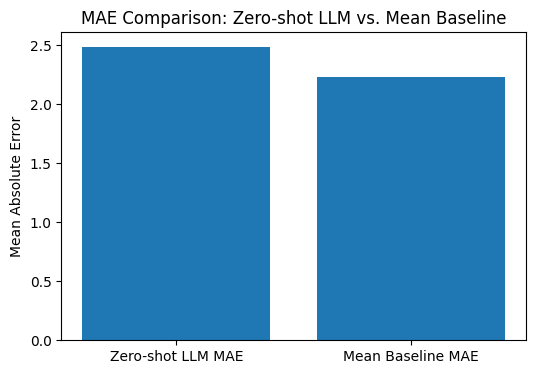



Zero-shot MSE: 9.405
Mean Baseline MSE: 8.083


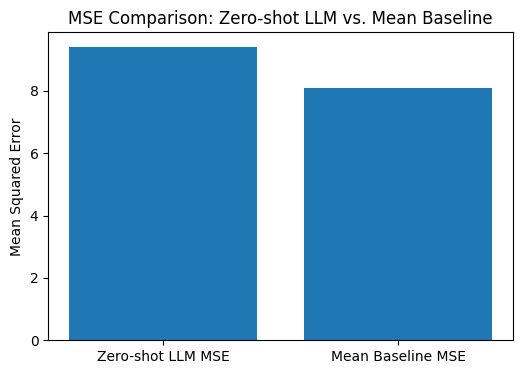

In [ ]:
eval_df = df.dropna(subset=["score_zero_shot"]).copy()

# Predict the mean score in the dataset
mean_points = eval_df["points"].mean()
eval_df["score_mean_baseline"] = mean_points

# compute MAE
eval_df['zero_shot_mae'] = abs(eval_df['score_zero_shot'] - eval_df['points'])
eval_df['mean_baseline_mae'] = abs(eval_df['score_mean_baseline'] - eval_df['points'])

print(f"Zero-shot MAE: {eval_df['zero_shot_mae'].mean():.3f}")
print(f"Mean Baseline MAE: {eval_df['mean_baseline_mae'].mean():.3f}")

# Visualization
plt.figure(figsize=(6, 4))
plt.bar(
    ["Zero-shot LLM MAE", "Mean Baseline MAE"],
    [eval_df['zero_shot_mae'].mean(), eval_df['mean_baseline_mae'].mean()]
)
plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison: Zero-shot LLM vs. Mean Baseline")
plt.show()

print('\n')

#compute MSE
eval_df['zero_shot_mse'] = (eval_df['score_zero_shot'] - eval_df['points'])**2
eval_df['mean_baseline_mse'] = (eval_df['score_mean_baseline'] - eval_df['points'])**2

print(f"Zero-shot MSE: {eval_df['zero_shot_mse'].mean():.3f}")
print(f"Mean Baseline MSE: {eval_df['mean_baseline_mse'].mean():.3f}")

# Visualization
plt.figure(figsize=(6, 4))
plt.bar(
    ["Zero-shot LLM MSE", "Mean Baseline MSE"],
    [eval_df['zero_shot_mse'].mean(), eval_df['mean_baseline_mse'].mean()]
)
plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison: Zero-shot LLM vs. Mean Baseline")
plt.show()

The zero-shot LLM and the mean baseline produce similar error metrics, with the mean baseline slightly outperforming the LLM. This reflects the narrow distribution of expert-assigned wine scores, where predicting the mean minimizes error for many observations. While the LLM captures some signal from textual descriptions, subjectivity in language and taste introduces additional noise that limits performance in a zero-shot setting.

## Scaling Zero-shot Inference with Asynchronous Requests

In [ ]:
import asyncio
import time
from openai import AsyncOpenAI

async_client = AsyncOpenAI(api_key=os.environ.get("OPENAI_API_KEY", ""))

async def predict_one(review_text: str, sem: asyncio.Semaphore):
    prompt = (
        "You are a quality rater for different wines.\n"
        "Task: Predict the quality score for the description.\n"
        "Label definition:\n"
        "- 80 = acceptable score\n"
        "- 100 = best score\n\n"
        "Return ONLY a number in the range: 80 - 100. No words, no punctuation, no extra text.\n\n"
        f"Review: {review_text}"
    )

    async with sem:
        resp = await async_client.responses.create(
            model="gpt-5-nano",
            input=prompt
        )
    return resp.output_text

async def predict_all_reviews(reviews, concurrency=100):
    sem = asyncio.Semaphore(concurrency)
    tasks = [predict_one(r, sem) for r in reviews]
    return await asyncio.gather(*tasks)

# Run concurrent prediction
t0 = time.perf_counter()
raw_outputs = await predict_all_reviews(df["description"].tolist(), concurrency=100)
t1 = time.perf_counter()

df["score_zero_shot_raw_concurrent"] = raw_outputs
df["score_zero_shot_concurrent"] = df["score_zero_shot_raw_concurrent"].apply(parse_score)

print(f"Concurrent run finished in {t1 - t0:.1f} seconds (concurrency=100).")
print("Number of parsing failures:", df["score_zero_shot_concurrent"].isna().sum())

df[["description", "points", "score_zero_shot_concurrent"]].head()

Concurrent run finished in 12.3 seconds (concurrency=100).
Number of parsing failures: 0


,description,points,score_zero_shot_concurrent
0,There's a surprising element of power to this ...,93,92
1,"Still youthful and vibrant, the 2007 Taylors P...",90,90
2,This is the rare Côtes du Rhône that needs cel...,90,92
3,"A rich, nutty note hints at hazelnut, with liv...",95,94
4,Powdered sugar and lifted lemon scents mark th...,83,88


Asynchronous execution enables many API calls to run in parallel, significantly reducing end-to-end runtime compared to sequential inference. This makes large-scale evaluation feasible without changing model behavior or prediction logic.

## Few-shot Prompting: Adding Anchors to the Rating Scale

In [ ]:
# Two few-shot examples
EXAMPLE_83_REVIEW = (
    "Possibly a little sweet, this is a soft, easygoing Chardonnay marked by clean, modest pear and melon flavors."
)
EXAMPLE_95_REVIEW = (
    "From Draper clone vines planted in 1965, this bright gold-hued wine brings myriad "
    "details to its apple, jicama, white peach and nut oil flavors. A whiff of smoke carries throughout, and "
    "its sheer complexity strains the vocabulary. Stay with it as more subtle layers unfold. Though seductive "
    "now, it should mature well through 2030."
)

async def predict_wine_few_shot(review_text: str, sem: asyncio.Semaphore):
    prompt = (
        "You are a quality rater for different wines.\n"
        "Task: Predict the quality score for the description.\n"
        "Label definition:\n"
        "- 80 = acceptable score\n"
        "- 100 = best score\n\n"
        "Example 1:\n"
        f"Description: {EXAMPLE_83_REVIEW}\n"
        "Score: 83\n\n"
        "Example 2:\n"
        f"Description: {EXAMPLE_95_REVIEW}\n"
        "Score: 95\n\n"
        "Now score the following description.\n"
        "Return ONLY a number in the range: 80 - 100. No words, no punctuation, no extra text.\n\n"
        f"Review: {review_text}"
    )

    async with sem:
        resp = await async_client.responses.create(
            model="gpt-5-nano",
            input=prompt
        )
    return resp.output_text

async def predict_all_few_shot(reviews, concurrency=100):
    sem = asyncio.Semaphore(concurrency)
    tasks = [predict_wine_few_shot(r, sem) for r in reviews]
    return await asyncio.gather(*tasks)

# Run few-shot prediction with concurrency
raw_few_shot = await predict_all_few_shot(df["description"].tolist(), concurrency=100)

df["score_few_shot_raw"] = raw_few_shot
df["score_few_shot"] = df["score_few_shot_raw"].apply(parse_score)

df[["description", "points", "score_zero_shot", "score_few_shot"]].head()

,description,points,score_zero_shot,score_few_shot
0,There's a surprising element of power to this ...,93,92,92
1,"Still youthful and vibrant, the 2007 Taylors P...",90,90,88
2,This is the rare Côtes du Rhône that needs cel...,90,92,91
3,"A rich, nutty note hints at hazelnut, with liv...",95,93,90
4,Powdered sugar and lifted lemon scents mark th...,83,92,88


In [ ]:
eval_df2 = df.dropna(subset=["score_zero_shot", "score_few_shot"]).copy()

mae_zero = np.mean(abs(eval_df2["score_zero_shot"] - eval_df2["points"]))
mae_few  = np.mean(abs(eval_df2["score_few_shot"]  - eval_df2["points"]))

mse_zero = np.mean((eval_df2["score_zero_shot"] - eval_df2["points"])**2)
mse_few  = np.mean((eval_df2["score_few_shot"]  - eval_df2["points"])**2)

print(f"Zero-shot MAE: {mae_zero:.3f}")
print(f"Few-shot  MAE: {mae_few:.3f}")

print('\n')

print(f"Zero-shot MSE: {mse_zero:.3f}")
print(f"Few-shot  MSE: {mse_few:.3f}")

Zero-shot MAE: 2.485
Few-shot  MAE: 2.305


Zero-shot MSE: 9.405
Few-shot  MSE: 8.295


Few-shot prompting yields modest improvements over zero-shot by providing concrete examples that anchor the model to the scoring scale. The gains are limited, which is consistent with the subjectivity and ambiguity of mapping tasting language to precise numeric ratings.

## Few-shot Prompting with Chain-of-Thought Reasoning

In [ ]:
async def predict_wine_few_shot_cot(review_text: str, sem: asyncio.Semaphore):
    prompt = (
        "You are a quality rater for different wines.\n"
        "Task: Predict the quality score for the description.\n"
        "Label definition:\n"
        "- 80 = acceptable score\n"
        "- 100 = best score\n\n"
        "Example 1:\n"
        f"Description: {EXAMPLE_83_REVIEW}\n"
        "Explanation: The wine is described as soft and easygoing with modest fruit flavors, "
        "suggesting decent quality but limited complexity.\n"
        "Score: 83\n\n"
        "Example 2:\n"
        f"Description: {EXAMPLE_95_REVIEW}\n"
        "Explanation: The description emphasizes complexity, age-worthy structure, and layered flavors, "
        "all of which are hallmarks of a high-quality wine.\n"
        "Score: 95\n\n"
        "Now evaluate the following description.\n"
        "First, briefly explain your assessment in 2–4 sentences.\n"
        "Then output the final score on a new line in the format:\n"
        "Score: <integer between 80 and 100>\n\n"
        f"Description: {review_text}"
    )

    async with sem:
        resp = await async_client.responses.create(
            model="gpt-5-nano",
            input=prompt
        )
    return resp.output_text

def extract_score_from_cot(x):
    if isinstance(x, str):
        m = re.search(r"Score:\s*(\d{2,3})", x)
        if m:
            val = int(m.group(1))
            if 80 <= val <= 100:
                return val
    return None

async def predict_all_few_shot_cot(reviews, concurrency=100):
    sem = asyncio.Semaphore(concurrency)
    tasks = [predict_wine_few_shot_cot(r, sem) for r in reviews]
    return await asyncio.gather(*tasks)

# Run few-shot CoT prediction with concurrency
raw_cot = await predict_all_few_shot_cot(df["description"].tolist(), concurrency=100)

df["score_few_shot_cot_raw"] = raw_cot
df["score_few_shot_cot"] = df["score_few_shot_cot_raw"].apply(extract_score_from_cot)

df[["description", "points", "score_few_shot", "score_few_shot_cot"]].head()

,description,points,score_few_shot,score_few_shot_cot
0,There's a surprising element of power to this ...,93,92,94
1,"Still youthful and vibrant, the 2007 Taylors P...",90,88,87
2,This is the rare Côtes du Rhône that needs cel...,90,91,90
3,"A rich, nutty note hints at hazelnut, with liv...",95,90,92
4,Powdered sugar and lifted lemon scents mark th...,83,88,87


In [ ]:
eval_df3 = df.dropna(subset=["score_few_shot", "score_few_shot_cot"]).copy()

mae_few_2 = np.mean(abs(eval_df3["score_few_shot"] - eval_df3["points"]))
mae_few_cot  = np.mean(abs(eval_df3["score_few_shot_cot"]  - eval_df3["points"]))

mse_few_2 = np.mean((eval_df3["score_few_shot"] - eval_df3["points"])**2)
mse_few_cot  = np.mean((eval_df3["score_few_shot_cot"]  - eval_df3["points"])**2)

print(f"Few-shot MAE: {mae_few_2:.3f}")
print(f"Few-shot-cot  MAE: {mae_few_cot:.3f}")

print('\n')

print(f"Few-shot MSE: {mse_few_2:.3f}")
print(f"Few-shot_cot  MSE: {mse_few_cot:.3f}")

Few-shot MAE: 2.305
Few-shot-cot  MAE: 2.185


Few-shot MSE: 8.295
Few-shot_cot  MSE: 7.345


Adding chain-of-thought reasoning to the few-shot prompt yields incremental improvements over standard few-shot prompting. Encouraging the model to articulate an intermediate assessment appears to improve alignment with human ratings, though gains remain modest due to the inherent subjectivity of the task.

## Prediction Variance Under Repeated Inference

In [ ]:
first_score = df.iloc[0]["description"]

# Run zero-shot prompt 20 times
scores = []
for i in range(20):
    raw_score = predict_wine_score_zero_shot(first_score)
    score = parse_score(raw_score)
    scores.append(score)

# Convert to numpy array
scores = np.array(scores)

print("Zero-shot predicted scores across 20 runs:")
print(scores)

# Drop failed parses, if any
valid_scores = scores[scores != None].astype(int)

# Compute variance (Bernoulli variance)
score_variance = np.var(valid_scores)

print(f"Variance of predicted scoress: {score_variance:.3f}")
print(f"Mean predicted score: {scores.mean():.3f}")

Zero-shot predicted scores across 20 runs:
[94 92 93 92 93 95 90 92 93 92 92 94 92 93 92 93 92 93 94 92]
Variance of predicted scoress: 1.127
Mean predicted score: 92.650


Repeated zero-shot inference on the same review produces small but non-zero variance in predicted scores. This variability reflects uncertainty in mapping subjective language to a precise numeric rating, even when the input text is fixed.